In [39]:
import pandas as pd 
clip_meta_df = pd.read_csv("../recordings_log.csv")
clip_meta_df.head()
clip_meta_df.columns = clip_meta_df.columns.str.strip().str.replace(" ", "_")
clip_meta_df = clip_meta_df.dropna(subset=["Outcome"])

In [40]:
import pandas as pd

# 📂 Load metadata
clip_meta_df = pd.read_csv("../recordings_log.csv")
clip_meta_df.tail()

# 🧹 Clean column names
clip_meta_df.columns = clip_meta_df.columns.str.strip().str.replace(" ", "_")

# 🧼 Drop rows missing 'Outcome'
clip_meta_df = clip_meta_df.dropna(subset=["Outcome"])

# 📁 Add file paths
clip_meta_df["Video_Path"] = "../" + clip_meta_df["Video_Filename"].str.strip()
clip_meta_df["Audio_Path"] = "../" + clip_meta_df["Audio_Filename"].str.strip()

# 🔧 Convert Outcome to numeric label
clip_meta_df["label"] = clip_meta_df["Outcome"].astype(int)

# 🧪 DEBUG BLOCK — inspect results
print("========== METADATA DEBUG ==========")
print("✅ DataFrame shape:", clip_meta_df.shape)
print("✅ Columns:", clip_meta_df.columns.tolist())
print("✅ Sample rows:")
print(clip_meta_df[["Video_Filename", "Audio_Filename", "label"]].head())
print("✅ Label value counts:")
print(clip_meta_df["label"].value_counts(dropna=False))
print("✅ Unique labels:", clip_meta_df["label"].unique())
print("✅ Sample Video_Filenames:", clip_meta_df["Video_Filename"].head().tolist())
print("✅ Sample Audio_Filenames:", clip_meta_df["Audio_Filename"].head().tolist())
print("====================================")


========== METADATA DEBUG ==========
✅ DataFrame shape: (256, 7)
✅ Columns: ['Timestamp', 'Audio_Filename', 'Video_Filename', 'Outcome', 'Video_Path', 'Audio_Path', 'label']
✅ Sample rows:
                          Video_Filename  \
0  CroppedClips\clip_20250722_124710.avi   
1  CroppedClips\clip_20250722_124740.avi   
2  CroppedClips\clip_20250722_124811.avi   
3  CroppedClips\clip_20250722_124825.avi   
4  CroppedClips\clip_20250722_124846.avi   

                           Audio_Filename  label  
0  CroppedAudio\audio_20250722_124710.wav      0  
1  CroppedAudio\audio_20250722_124740.wav      0  
2  CroppedAudio\audio_20250722_124811.wav      0  
3  CroppedAudio\audio_20250722_124825.wav      0  
4  CroppedAudio\audio_20250722_124846.wav      0  
✅ Label value counts:
label
1    141
0    115
Name: count, dtype: int64
✅ Unique labels: [0 1]
✅ Sample Video_Filenames: ['CroppedClips\\clip_20250722_124710.avi', 'CroppedClips\\clip_20250722_124740.avi', 'CroppedClips\\clip_20250722_12481

In [45]:
import librosa
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def extract_mfcc(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfcc, axis=1)  # Clip-level summary

audio_features = []

for idx, row in clip_meta_df.iterrows():
    audio_path = row["Audio_Path"]
    video_name = row["Video_Filename"]
    label = row.get("label", None)

    try:
        mfcc_vec = extract_mfcc(audio_path)
        audio_features.append({
            "Video_Filename": video_name,
            "label": label,
            **{f"mfcc_{i}": mfcc_vec[i] for i in range(len(mfcc_vec))}
        })
    except Exception as e:
        print(f"⚠️ MFCC extraction failed on {audio_path}: {e}")

audio_df = pd.DataFrame(audio_features)

X_audio = audio_df[[f"mfcc_{i}" for i in range(13)]]
y_audio = audio_df["label"]

audio_model = RandomForestClassifier(random_state=42)
audio_model.fit(X_audio, y_audio)

# Predict deception probability
audio_df["audio_pred"] = audio_model.predict_proba(X_audio)[:, 1]  # assuming class 1 = deception

audio_pred_list = audio_df["audio_pred"].to_list()

audio_df.head()

,Video_Filename,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,audio_pred
0,CroppedClips\clip_20250722_124710.avi,0,-443.265900,56.664082,-17.217901,13.718971,-6.519683,-3.886679,-10.582273,-29.840578,-12.004639,0.837918,-10.145561,-7.091199,-2.527986,0.17
1,CroppedClips\clip_20250722_124740.avi,0,-684.949036,53.253754,-2.427891,-1.850195,3.063167,-0.970450,-15.641531,-10.608442,-4.013901,-5.318762,-5.764741,-3.139401,-6.564482,0.16
2,CroppedClips\clip_20250722_124811.avi,0,-579.864868,71.057129,-5.618330,-5.488316,-6.368209,-7.878674,-25.342104,-11.862755,-6.414837,-2.586096,-17.548067,-9.078303,4.620286,0.27
3,CroppedClips\clip_20250722_124825.avi,0,-568.717102,46.314335,-1.432767,2.496445,-7.141501,-0.892620,-13.783896,-13.445086,-3.848600,-4.180815,-12.204113,-5.216664,3.437464,0.23
4,CroppedClips\clip_20250722_124846.avi,0,-503.738922,61.163746,-3.829136,12.440789,-16.666857,-10.564239,-20.324402,-16.866842,-14.176570,-12.975049,-20.252930,-3.731543,9.131951,0.28


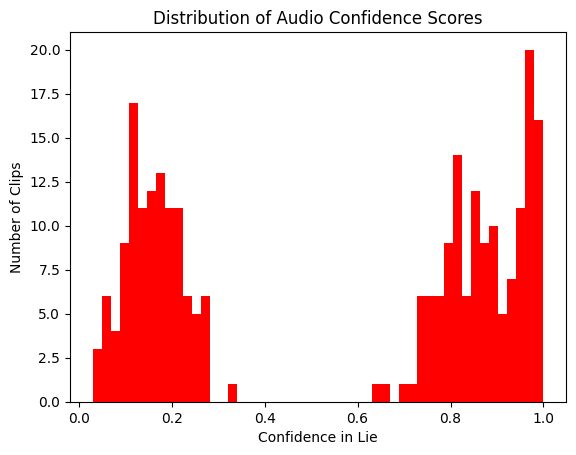

In [47]:
import matplotlib.pyplot as plt
plt.hist(audio_pred_list, bins=50, color='red')
plt.title("Distribution of Audio Confidence Scores")
plt.xlabel("Confidence in Lie")
plt.ylabel("Number of Clips")
plt.show()

In [42]:
from xgboost import XGBClassifier
import pandas as pd

# 🚀 Load model
face_model = XGBClassifier()
face_model.load_model("xgb_face_model.json")

# 📂 Load landmark features
landmark_df = pd.read_csv("normalized_landmark_data_with_motion.csv")

# 🧠 Extract features and predict
X_face = landmark_df.drop(columns=["Video_Filename", "frame", "label"])
landmark_df["face_score"] = face_model.predict_proba(X_face)[:, 1]

# 🔄 Average predictions per video
face_preds = landmark_df.groupby("Video_Filename")["face_score"].mean().reset_index()

face_score_list = landmark_df["face_score"].to_list()


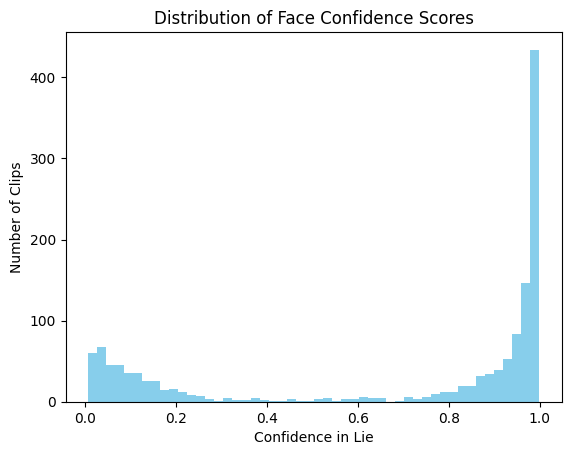

In [43]:
import matplotlib.pyplot as plt
plt.hist(face_score_list, bins=50, color='skyblue')
plt.title("Distribution of Face Confidence Scores")
plt.xlabel("Confidence in Lie")
plt.ylabel("Number of Clips")
plt.show()

In [48]:
# Standardize video keys
clip_meta_df["Video_Filename"] = clip_meta_df["Video_Filename"].str.replace("CroppedClips\\", "", regex=False)
audio_df["Video_Filename"] = audio_df["Video_Filename"].str.replace("CroppedClips\\", "", regex=False).str.strip()
face_preds["Video_Filename"] = face_preds["Video_Filename"].str.strip()
audio_df["Video_Filename"] = audio_df["Video_Filename"].str.strip()

print("Metadata size:", clip_meta_df.shape[0])
print("Face preds size:", face_preds.shape[0])
print("Audio preds size:", audio_df.shape[0])

# Check matching keys
print("Videos in metadata:", set(clip_meta_df["Video_Filename"][:5]))
print("Videos in face_preds:", set(face_preds["Video_Filename"][:5]))

print("\n✅ Sample keys from each source:")
print("Metadata keys:", set(clip_meta_df["Video_Filename"][:10]))
print("Face preds keys:", set(face_preds["Video_Filename"][:10]))
print("Audio preds keys:", set(audio_df["Video_Filename"][:10]))

# Optional: intersection size
print("🔗 Face ∩ Metadata:", len(set(face_preds["Video_Filename"]) & set(clip_meta_df["Video_Filename"])))
print("🔗 Audio ∩ Metadata:", len(set(audio_df["Video_Filename"]) & set(clip_meta_df["Video_Filename"])))



Metadata size: 256
Face preds size: 225
Audio preds size: 256
Videos in metadata: {'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_124846.avi', 'clip_20250722_124710.avi', 'clip_20250722_124740.avi'}
Videos in face_preds: {'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_124846.avi', 'clip_20250722_124710.avi', 'clip_20250722_124740.avi'}

✅ Sample keys from each source:
Metadata keys: {'clip_20250722_125014.avi', 'clip_20250722_124908.avi', 'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_125124.avi', 'clip_20250722_124846.avi', 'clip_20250722_124927.avi', 'clip_20250722_124710.avi', 'clip_20250722_124740.avi', 'clip_20250722_125035.avi'}
Face preds keys: {'clip_20250722_125014.avi', 'clip_20250722_124908.avi', 'clip_20250722_124811.avi', 'clip_20250722_124825.avi', 'clip_20250722_125124.avi', 'clip_20250722_124846.avi', 'clip_20250722_124927.avi', 'clip_20250722_124710.avi', 'clip_20250722_124740.avi', 'clip_20250722_

In [49]:
# 📦 Start with metadata + labels
ensemble_df = clip_meta_df[["Video_Filename", "label"]].copy()

# 🧠 Merge facial predictions
ensemble_df = ensemble_df.merge(
    face_preds[["Video_Filename", "face_score"]],
    on="Video_Filename",
    how="inner"
)

# 🔊 Merge audio features
ensemble_df = ensemble_df.merge(
    audio_df[["Video_Filename"] + ["audio_pred"]],
    on="Video_Filename",
    how="inner"
)

# 🎯 Final stacked inputs and target
X_stack = ensemble_df[["face_score"] + ["audio_pred"]]
y_stack = ensemble_df["label"]

# ✅ Sanity check
print("✅ Final ensemble shape:", ensemble_df.shape)
print("✅ Label distribution:\n", y_stack.value_counts(dropna=False))
print("✅ Sample stacked features:\n", X_stack.head())


✅ Final ensemble shape: (303, 4)
✅ Label distribution:
 label
1    192
0    111
Name: count, dtype: int64
✅ Sample stacked features:
    face_score  audio_pred
0    0.114360        0.17
1    0.050318        0.16
2    0.062310        0.27
3    0.244636        0.23
4    0.046229        0.28


In [50]:
print("Final columns:", ensemble_df.columns)
print("Label counts:", y_stack.value_counts())


Final columns: Index(['Video_Filename', 'label', 'face_score', 'audio_pred'], dtype='object')
Label counts: label
1    192
0    111
Name: count, dtype: int64


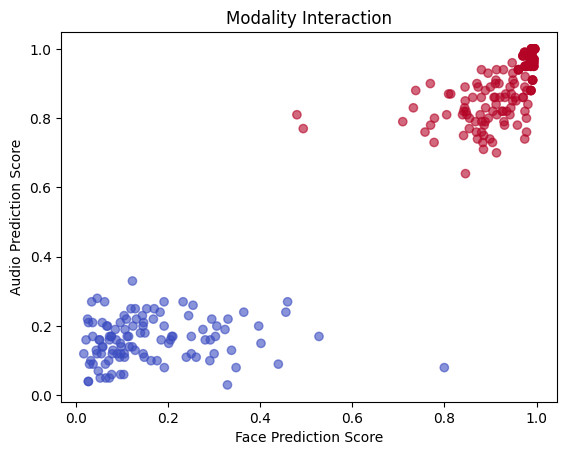

In [51]:
import matplotlib.pyplot as plt

plt.scatter(ensemble_df["face_score"], ensemble_df["audio_pred"], c=ensemble_df["label"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Face Prediction Score")
plt.ylabel("Audio Prediction Score")
plt.title("Modality Interaction")
plt.show()

In [58]:
def get_modality_clash(row):
    face_vote = row["face_score"] > 0.5
    audio_vote = row["audio_pred"] > 0.5
    return face_vote != audio_vote  # True if they disagree
ensemble_df["modality_clash"] = ensemble_df.apply(get_modality_clash, axis=1)

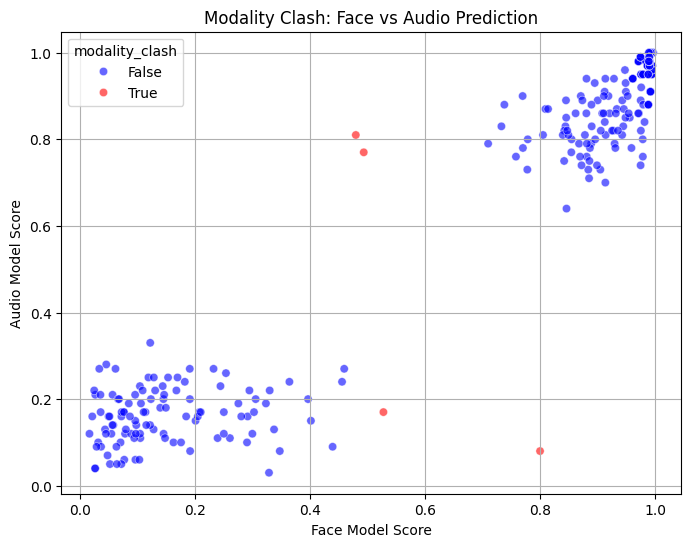

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=ensemble_df,
    x="face_score",
    y="audio_pred",
    hue="modality_clash",  # True if face ≠ audio
    palette={True: "red", False: "blue"},
    alpha=0.6
)
plt.title("Modality Clash: Face vs Audio Prediction")
plt.xlabel("Face Model Score")
plt.ylabel("Audio Model Score")
plt.grid(True)
plt.show()


In [69]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 🔄 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_stack, y_stack, test_size=0.2, stratify=y_stack, random_state=42
)

# ⚙️ Initialize and train XGBoost
stacked_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handling class imbalance
    use_label_encoder=False,
    eval_metric="logloss"
)

stacked_model.fit(X_train, y_train)

# 🧪 Evaluate performance
y_pred = stacked_model.predict(X_test)

print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred))

print("✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



✅ Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        39

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61

✅ Confusion Matrix:
[[22  0]
 [ 0 39]]


C:\Users\connellj2\OneDrive - Wentworth Institute of Technology\Documents\DecepTech\decep_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:52:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: Accuracy = {score:.3f}")


Logistic Regression: Accuracy = 1.000
SVM: Accuracy = 1.000
Random Forest: Accuracy = 1.000


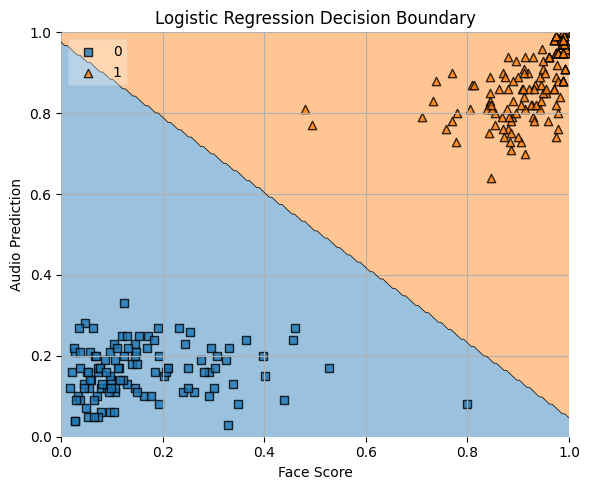

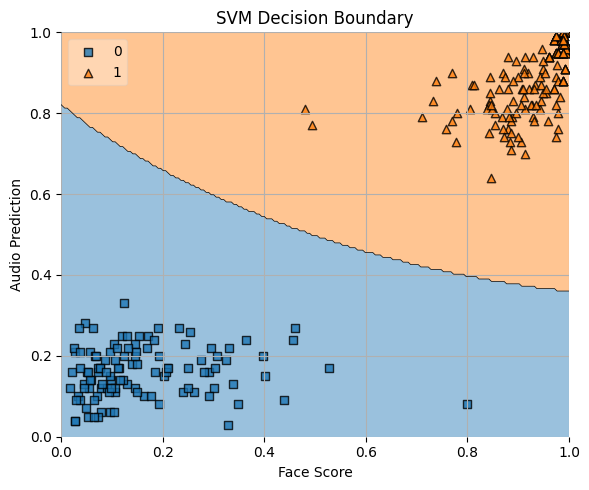

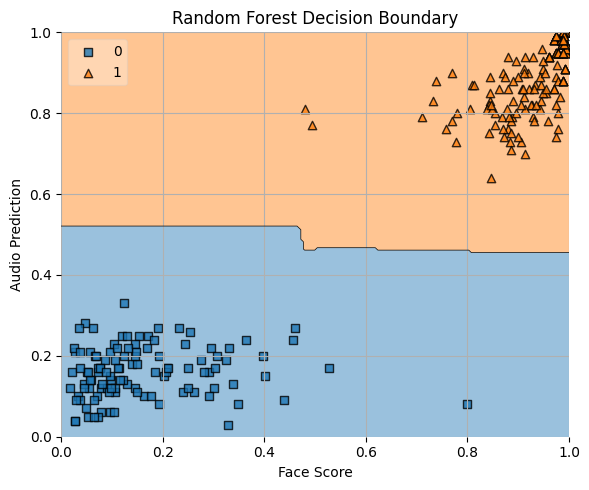

In [77]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

X = ensemble_df[["face_score", "audio_pred"]].values
y = ensemble_df["label"].values

models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}


for name, clf in models.items():
    clf.fit(X, y)
    plt.figure(figsize=(6,5))
    plot_decision_regions(X, y, clf=clf, legend=2)
    plt.title(f"{name} Decision Boundary")
    plt.xlabel("Face Score")
    plt.ylabel("Audio Prediction")
    plt.grid(True)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


In [66]:
import joblib

joblib.dump(stacked_model, "stacked_model.pkl")

['stacked_model.pkl']

In [67]:
joblib.dump(audio_model, "audio_model.pkl")

['audio_model.pkl']

In [79]:
lr_model = models["Logistic Regression"]
joblib.dump(lr_model, "stacked_model_linear.pkl")

['stacked_model_linear.pkl']